In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
from sqlalchemy import create_engine 
from dotenv import load_dotenv 
import os 
import matplotlib.ticker as ticker

In [2]:
raw_data = Path(r'C:\Users\falce\OneDrive\Desktop\Progetti_Data_analyst\Analisi_energia')

In [3]:
load_dotenv(raw_data/'db.env') 

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
database = os.getenv('DB_NAME')

engine_url = f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}'

engine = create_engine(engine_url)

In [4]:
query1 = """select
year,
source,
round(sum(production_gwh)::numeric, 1) as production_gwh 
from production_data
group by year, source order by year"""

prod_by_source_year = pd.read_sql(query1, con=engine)
prod_by_source_year.head()

,year,source,production_gwh
0,2000,Fotovoltaico,6.3
1,2000,Termoelettrico,220454.9
2,2000,Eolico,563.1
3,2000,Idrico,50899.6
4,2000,Geotermoelettrico,4705.2


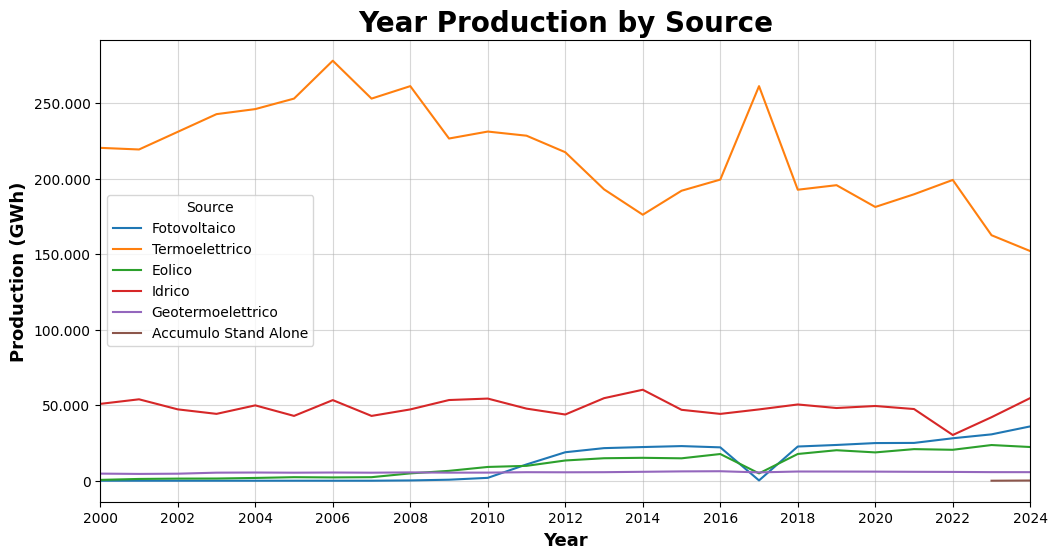

In [5]:
xyears = range(2000,2025,2)
fig, ax = plt.subplots(figsize=(12,6))

sns.lineplot(data=prod_by_source_year, x="year", y="production_gwh", hue='source', ax=ax)
ax.set_title('Year Production by Source', size=20, fontweight="bold")
ax.set_xlabel('Year', size=13, fontweight="bold")
ax.set_ylabel('Production (GWh)', size=13, fontweight="bold")
ax.set_xlim(2000, 2024) #imposta i limiti min e max dell'asse x
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(
    lambda x, p: format(int(x), ',').replace(',', '.'))) #metto il punto alle migliaia
plt.grid(alpha=0.5)
ax.legend(title='Source')
ax.set_xticks(xyears)
plt.savefig(raw_data/'Visuals'/'Year_Production_by_Source.png');

In [6]:
query2 = """
select
year,
sector,
round(sum(consumption_gwh)::numeric, 1) as consumption_gwh
from consumption_data
group by sector, year
order by year """

cons_by_sector_year = pd.read_sql(query2, con=engine)

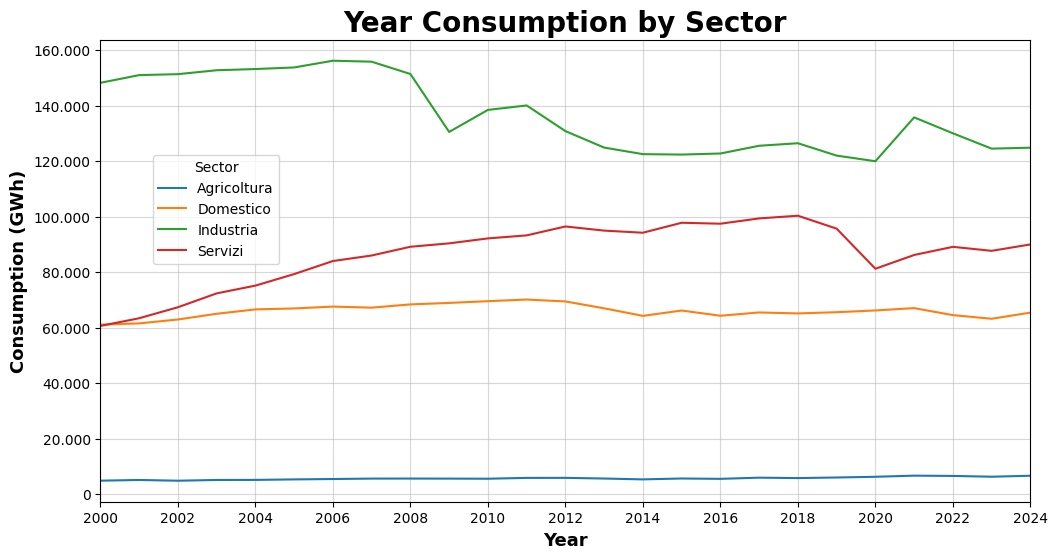

In [7]:
xyears = range(2000,2025,2)

fig, ax = plt.subplots(figsize=(12,6))

sns.lineplot(data=cons_by_sector_year, x='year', y='consumption_gwh', hue='sector', ax=ax)
ax.set_title('Year Consumption by Sector', size=20, fontweight='bold')
ax.set_xlabel('Year', size=13, fontweight='bold')
ax.set_ylabel('Consumption (GWh)', size=13, fontweight='bold')
ax.set_xlim(2000,2024)
ax.set_xticks(xyears)
ax.legend(title= 'Sector', bbox_to_anchor=(0.2,0.5))
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(
    lambda x, p: format(int(x), ',').replace(',', '.')))
plt.grid(alpha=0.5)
plt.savefig(raw_data/'Visuals'/'Year_Consumption_by_Sector.png');

In [8]:
query3 = """
with
	production as (
	select
	region,
	sum(production_gwh) as production_gwh
	from production_data
	where year >= 2020 and 
	source != 'Termoelettrico' and 
	source != 'Accumulo Stand Alone'
	group by region
		),

	consumption as (
	select
	region,
	sum(consumption_gwh) as consumption_gwh
	from consumption_data
	where year >= 2020
	group by region
	)

select
p.region,
round(((p.production_gwh/c.consumption_gwh)*100)::numeric, 1) as renewable_coverage_pct
from production p
join consumption c
on p.region = c.region
order by renewable_coverage_pct"""

renewable_coverage = pd.read_sql(query3, con=engine)
renewable_coverage.head()

,region,renewable_coverage_pct
0,liguria,9.7
1,emilia-romagna,13.7
2,lazio,16.1
3,lombardia,21.6
4,veneto,22.4


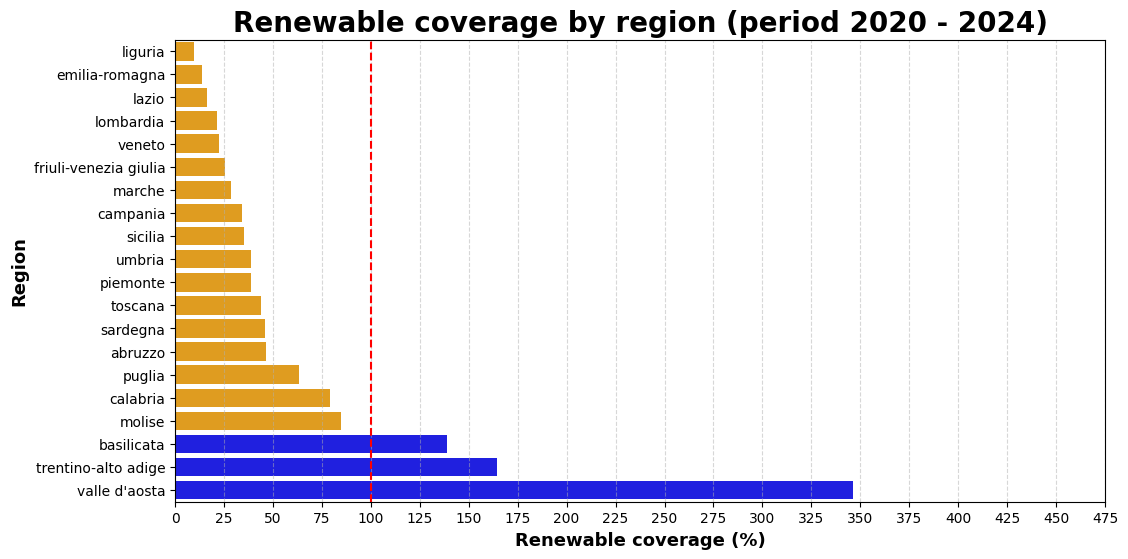

In [9]:
colors = ['orange' if v < 100 else 'blue' for v in renewable_coverage['renewable_coverage_pct']] 

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=renewable_coverage, x='renewable_coverage_pct', y='region', ax=ax, palette=colors, hue='region', legend=False)
ax.set_title('Renewable coverage by region (period 2020 - 2024)', size=20, fontweight='bold')
ax.set_xlabel('Renewable coverage (%)', size=13, fontweight='bold')
ax.set_ylabel('Region', size=13, fontweight='bold')
plt.grid(axis='x', alpha=0.5, ls='--')
ax.set_xticks(range(0,500,25))
ax.axvline(x=100, ls='--', color='r')
plt.savefig(raw_data/'Visuals'/'Renewable_coverage_by_region.png');